In [1]:
import os, math, random, gc, shutil, sys
import numpy as np
import pandas as pd
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms, models, datasets
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from sklearn.metrics import (cohen_kappa_score, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report)

In [2]:
DATASET_DIR   = '/kaggle/input/datasets/tommyngx/kneeoa'
TRAIN_DIR     = f'{DATASET_DIR}/train'
VAL_DIR       = f'{DATASET_DIR}/val'
TEST_DIR      = f'{DATASET_DIR}/test'
AUTO_TEST_DIR = f'{DATASET_DIR}/auto_test'
CKPT_DIR      = '/kaggle/working'

CLASS_NAMES    = ['0', '1', '2', '3', '4']
DISPLAY_NAMES  = [
    'Grade 0 (Healthy)',
    'Grade 1 (Doubtful)',
    'Grade 2 (Minimal)',
    'Grade 3 (Moderate)',
    'Grade 4 (Severe)',
]
NUM_CLASSES  = len(CLASS_NAMES)

device       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE   = 64
NUM_EPOCHS   = 100
LR           = 0.001
WEIGHT_DECAY = 1e-4
TEMPERATURE = 5.0
ALPHA       = 0.5
DROPOUT     = 0.3
USE_AMP      = torch.cuda.is_available()
os.makedirs(CKPT_DIR, exist_ok=True)
print(f"Device: {device} | AMP: {USE_AMP}")

Device: cpu | AMP: False


In [3]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    

def cleanup_memory():
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

def _compute_mse_rmse(labels, preds):
    labels_arr = np.array(labels, dtype=np.float32)
    preds_arr  = np.array(preds,  dtype=np.float32)
    mse  = float(np.mean((labels_arr - preds_arr) ** 2))
    rmse = float(np.sqrt(mse))
    mae  = float(np.mean(np.abs(labels_arr - preds_arr)))
    return mse, rmse, mae

In [4]:
train_tfm = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.9, 1.0), ratio=(0.95, 1.05)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.RandomApply([transforms.GaussianBlur(3)], p=0.3),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.08), value='random'),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])
val_tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_tfm)
val_dataset   = datasets.ImageFolder(VAL_DIR,   transform=val_tfm)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=val_tfm)

assert train_dataset.classes == CLASS_NAMES, (
    f"Folder classes {train_dataset.classes} don't match CLASS_NAMES {CLASS_NAMES}"
)

train_labels   = [label for _, label in train_dataset.samples]
class_counts   = np.bincount(train_labels, minlength=NUM_CLASSES)
sample_weights = np.array([1.0 / class_counts[lbl] for lbl in train_labels])
sampler = WeightedRandomSampler(
    torch.tensor(sample_weights, dtype=torch.float),
    num_samples=len(sample_weights),
    replacement=True,
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=4, pin_memory=True)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print("Class distribution (train):")
for i, name in enumerate(DISPLAY_NAMES):
    n   = class_counts[i]
    bar = '█' * int(30 * n / len(train_dataset))
    print(f"  [{i}] {name:<25s}: {n:4d} ({100*n/len(train_dataset):5.1f}%)  {bar}")

Train: 5778 | Val: 826 | Test: 1656
Class distribution (train):
  [0] Grade 0 (Healthy)        : 2286 ( 39.6%)  ███████████
  [1] Grade 1 (Doubtful)       : 1046 ( 18.1%)  █████
  [2] Grade 2 (Minimal)        : 1516 ( 26.2%)  ███████
  [3] Grade 3 (Moderate)       :  757 ( 13.1%)  ███
  [4] Grade 4 (Severe)         :  173 (  3.0%)  


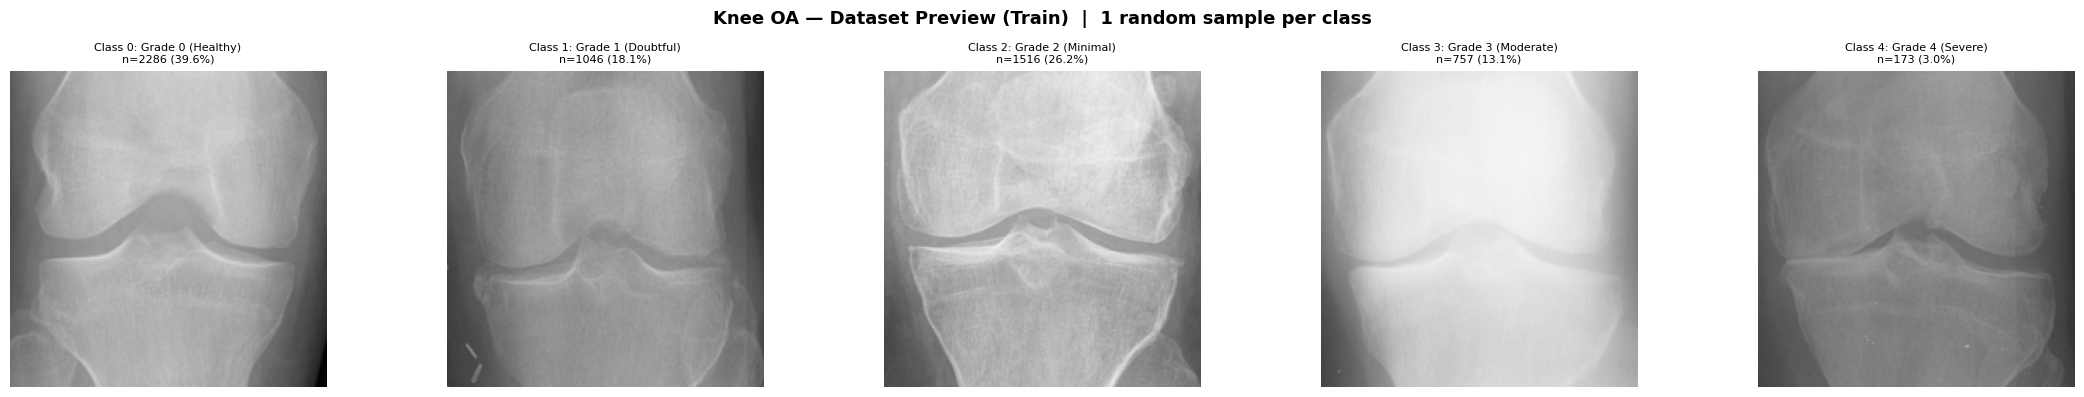

In [5]:
def preview_dataset(dataset, split_name="Train"):
    """Show one random sample per class directly from an ImageFolder dataset."""
    fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(22, 4))
    fig.suptitle(
        f"Knee OA — Dataset Preview ({split_name})  |  1 random sample per class",
        fontsize=13, fontweight='bold'
    )
    # Group indices by class
    from collections import defaultdict
    cls_to_indices = defaultdict(list)
    for idx, (_, label) in enumerate(dataset.samples):
        cls_to_indices[label].append(idx)

    for cls_idx, disp_name in enumerate(DISPLAY_NAMES):
        indices = cls_to_indices[cls_idx]
        pick    = random.choice(indices)
        img_path, _ = dataset.samples[pick]
        img = Image.open(img_path).convert('RGB')
        axes[cls_idx].imshow(img)
        axes[cls_idx].set_title(
            f"Class {cls_idx}: {disp_name}\nn={len(indices)} "
            f"({100*len(indices)/len(dataset):.1f}%)",
            fontsize=8
        )
        axes[cls_idx].axis('off')

    plt.tight_layout()
    plt.savefig(f'{CKPT_DIR}/dataset_preview.png', dpi=120, bbox_inches='tight')
    plt.show()

preview_dataset(train_dataset, "Train")

In [6]:
LABELS = DISPLAY_NAMES

def analyse_results(results_list, scenario_title, loss_label="Loss",
                    teacher_accs=None, test_results_list=None):
    seeds      = [r['seed'] for r in results_list]
    all_losses = np.array([r['history']['train_loss'] for r in results_list])
    all_qwks   = np.array([r['history']['val_qwk']    for r in results_list])
    all_accs   = np.array([r['history']['val_acc']    for r in results_list])
    all_rmses  = np.array([r['history']['val_rmse']   for r in results_list])
    all_maes   = np.array([r['history']['val_mae']    for r in results_list])
    epochs     = np.arange(1, all_losses.shape[1] + 1)
    best_res   = max(results_list, key=lambda x: x['qwk'])
    colors     = plt.cm.tab10.colors

    cms = [confusion_matrix(r['labels'], r['preds'], labels=list(range(NUM_CLASSES)))
           for r in results_list]
    cm_avg      = np.mean(cms, axis=0)
    cm_std      = np.std(cms,  axis=0)
    cm_avg_norm = cm_avg / cm_avg.sum(axis=1, keepdims=True)
    cm_best     = confusion_matrix(best_res['labels'], best_res['preds'],
                                   labels=list(range(NUM_CLASSES)))

    seed_accs  = [np.mean(np.array(r['labels']) == np.array(r['preds'])) * 100 for r in results_list]
    mean_acc   = np.mean(seed_accs);  std_acc  = np.std(seed_accs)
    mean_qwk   = np.mean([r['qwk'] for r in results_list])
    std_qwk    = np.std([r['qwk']  for r in results_list])

    best_rmses = [r['history']['val_rmse'][np.argmax(r['history']['val_qwk'])] for r in results_list]
    best_maes  = [r['history']['val_mae'] [np.argmax(r['history']['val_qwk'])] for r in results_list]
    mean_rmse  = np.mean(best_rmses); std_rmse = np.std(best_rmses)
    mean_mae   = np.mean(best_maes);  std_mae  = np.std(best_maes)

    per_cls_acc = cm_avg.diagonal() / cm_avg.sum(axis=1)

    misclass = []
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            if i != j and cm_avg[i, j] > 0:
                misclass.append((cm_avg[i, j], i, j))
    misclass.sort(reverse=True)

    report = classification_report(best_res['labels'], best_res['preds'],
                                   target_names=DISPLAY_NAMES, output_dict=True)

    CKPT_SAFE = scenario_title.replace(' ', '_').replace('/', '_').replace('(', '').replace(')', '')

    # ── Figure 1: Training Dashboard ─────────────────────────────────────────
    fig1 = plt.figure(figsize=(24, 18))
    fig1.suptitle(f"{scenario_title}\n— Training Analysis Dashboard —",
                  fontsize=16, fontweight='bold', y=0.99)
    gs1 = gridspec.GridSpec(4, 4, figure=fig1, hspace=0.50, wspace=0.30)

    # [0,0] val accuracy boxplot
    ax = fig1.add_subplot(gs1[0, 0])
    bp = ax.boxplot([seed_accs], patch_artist=True, widths=0.4,
                    medianprops=dict(color='red', lw=2))
    bp['boxes'][0].set_facecolor('#aec6e8')
    ax.scatter([1] * len(seed_accs), seed_accs, color='black', s=40, zorder=5)
    ax.set_xticks([1]); ax.set_xticklabels(['Student'])
    ax.set_title(f"Val Accuracy Distribution\n({len(seeds)} Seeds)", fontsize=11, fontweight='bold')
    ax.set_ylabel("Accuracy (%)")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
    ax.grid(True, axis='y', ls='--', alpha=0.5)
    ax.text(1, mean_acc, f"μ={mean_acc:.2f}%\nσ={std_acc:.2f}%",
            ha='center', va='bottom', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))

    # [0,1] QWK boxplot or teacher vs student
    ax = fig1.add_subplot(gs1[0, 1])
    if teacher_accs:
        names  = [f"Teacher {i+1}" for i in range(len(teacher_accs))] + ['Student']
        values = list(teacher_accs) + [mean_acc]
        bar_colors = ['#4878CF'] * len(teacher_accs) + ['#F8A60B']
        bars = ax.bar(range(len(names)), values, color=bar_colors, width=0.5,
                      edgecolor='white', lw=1.5)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f"{val:.2f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax.set_xticks(range(len(names)))
        ax.set_xticklabels(names, rotation=15, ha='right', fontsize=9)
        ax.set_ylim(min(values) - 5, 100)
        ax.set_title("Teacher vs Student Accuracy", fontsize=11, fontweight='bold')
        ax.set_ylabel("Accuracy (%)")
    else:
        seed_qwks = [r['qwk'] for r in results_list]
        bp2 = ax.boxplot([seed_qwks], patch_artist=True, widths=0.4,
                         medianprops=dict(color='red', lw=2))
        bp2['boxes'][0].set_facecolor('#b8d4a8')
        ax.scatter([1] * len(seed_qwks), seed_qwks, color='black', s=40, zorder=5)
        ax.set_xticks([1]); ax.set_xticklabels(['Student'])
        ax.set_title(f"Val QWK Distribution\n({len(seeds)} Seeds)", fontsize=11, fontweight='bold')
        ax.set_ylabel("Quadratic Weighted Kappa")
        ax.text(1, mean_qwk, f"μ={mean_qwk:.4f}\nσ={std_qwk:.4f}",
                ha='center', va='bottom', fontsize=8.5,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))
    ax.grid(True, axis='y', ls='--', alpha=0.5)

    # [0,2] val accuracy curves
    ax = fig1.add_subplot(gs1[0, 2])
    mean_a = all_accs.mean(0) * 100; std_a = all_accs.std(0) * 100
    ax.plot(epochs, mean_a, color='#1f77b4', lw=2.2, label='Mean')
    ax.fill_between(epochs, mean_a - std_a, mean_a + std_a,
                    alpha=0.25, color='#1f77b4', label='±1 std')
    ax.set_title("Validation Accuracy Curves", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("Validation Accuracy (%)")
    ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.5)

    # [0,3] training loss
    ax = fig1.add_subplot(gs1[0, 3])
    mean_l = all_losses.mean(0); std_l = all_losses.std(0)
    ax.plot(epochs, mean_l, color='blue', lw=2.0, label=loss_label)
    ax.fill_between(epochs, mean_l - std_l, mean_l + std_l, alpha=0.15, color='blue')
    ax.set_title("Training Loss (Averaged)", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss Value")
    ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.5)

    # [1,0] rmse over epochs
    ax = fig1.add_subplot(gs1[1, 0])
    mean_rmse_curve = all_rmses.mean(0); std_rmse_curve = all_rmses.std(0)
    ax.plot(epochs, mean_rmse_curve, color='#d62728', lw=2.0, label='Mean RMSE')
    ax.fill_between(epochs, mean_rmse_curve - std_rmse_curve,
                    mean_rmse_curve + std_rmse_curve, alpha=0.2, color='#d62728')
    ax.set_title("Validation RMSE Over Epochs", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("RMSE")
    ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.5)

    # [1,1] mae over epochs
    ax = fig1.add_subplot(gs1[1, 1])
    mean_mae_curve = all_maes.mean(0); std_mae_curve = all_maes.std(0)
    ax.plot(epochs, mean_mae_curve, color='#ff7f0e', lw=2.0, label='Mean MAE')
    ax.fill_between(epochs, mean_mae_curve - std_mae_curve,
                    mean_mae_curve + std_mae_curve, alpha=0.2, color='#ff7f0e')
    ax.set_title("Validation MAE Over Epochs", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("MAE")
    ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.5)

    # [1,2] individual run val curves
    ax = fig1.add_subplot(gs1[1, 2])
    for i, r in enumerate(results_list):
        ax.plot(epochs, [a * 100 for a in r['history']['val_acc']],
                color=colors[i], lw=1.5, alpha=0.8, label=f"Run {i+1}")
    ax.plot(epochs, mean_a, 'k--', lw=2.2, label='Average')
    ax.set_title("Individual Run Validation Curves", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
    ax.legend(fontsize=8); ax.grid(True, ls='--', alpha=0.5)

    # [1,3] qwk / loss ratio
    ax = fig1.add_subplot(gs1[1, 3])
    ratio = all_qwks.mean(0) / (all_losses.mean(0) + 1e-8)
    ax.plot(epochs, ratio, color='purple', lw=1.8)
    ax.set_title("QWK / Loss Ratio Over Training", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("QWK / Loss Ratio")
    ax.grid(True, ls='--', alpha=0.5)

    # [2,0] avg confusion matrix raw
    ax = fig1.add_subplot(gs1[2, 0])
    im = ax.imshow(cm_avg, cmap='Blues', interpolation='nearest')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=7.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=7.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title("Average Confusion Matrix\n(Raw Counts)", fontsize=11, fontweight='bold')
    thresh = cm_avg.max() / 2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_avg[i,j]:.0f}", ha='center', va='center', fontsize=8,
                    color='white' if cm_avg[i,j] > thresh else 'black')

    # [2,1] avg confusion matrix normalized
    ax = fig1.add_subplot(gs1[2, 1])
    im2 = ax.imshow(cm_avg_norm, cmap='Blues', interpolation='nearest', vmin=0, vmax=1)
    plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=7.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=7.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title("Average Confusion Matrix\n(Normalized)", fontsize=11, fontweight='bold')
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_avg_norm[i,j]:.3f}", ha='center', va='center', fontsize=7.5,
                    color='white' if cm_avg_norm[i,j] > 0.5 else 'black')

    # [2,2] confusion matrix std
    ax = fig1.add_subplot(gs1[2, 2])
    im3 = ax.imshow(cm_std, cmap='Oranges', interpolation='nearest')
    plt.colorbar(im3, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=7.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=7.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title("Confusion Matrix\nStandard Deviation", fontsize=11, fontweight='bold')
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_std[i,j]:.2f}", ha='center', va='center', fontsize=7.5)

    # [2,3] best run confusion matrix
    ax = fig1.add_subplot(gs1[2, 3])
    im4 = ax.imshow(cm_best, cmap='Greens', interpolation='nearest')
    plt.colorbar(im4, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=7.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=7.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    best_acc = np.mean(np.array(best_res['labels']) == np.array(best_res['preds'])) * 100
    ax.set_title(f"Best Run CM (Seed {best_res['seed']}: {best_acc:.2f}%)",
                 fontsize=11, fontweight='bold')
    thresh2 = cm_best.max() / 2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_best[i,j]}", ha='center', va='center', fontsize=8,
                    color='white' if cm_best[i,j] > thresh2 else 'black')

    # [3,0] per-class accuracy bar
    ax = fig1.add_subplot(gs1[3, 0])
    bar_colors_cls = ['#d4edda' if a >= 0.7 else ('#fff3cd' if a >= 0.5 else '#f8d7da')
                      for a in per_cls_acc]
    bars = ax.bar(range(NUM_CLASSES), per_cls_acc * 100, color=bar_colors_cls,
                  edgecolor='grey', lw=0.8)
    for bar, val in zip(bars, per_cls_acc):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{val*100:.1f}%", ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title("Per-Class Accuracy\n(from Averaged CM)", fontsize=11, fontweight='bold')
    ax.set_ylabel("Accuracy (%)"); ax.set_ylim(0, 115)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8)
    ax.grid(True, axis='y', ls='--', alpha=0.5)

    # [3,1] per-class F1 bar
    ax = fig1.add_subplot(gs1[3, 1])
    f1_scores = [report[disp]['f1-score'] for disp in DISPLAY_NAMES]
    f1_colors = ['#d4edda' if f >= 0.7 else ('#fff3cd' if f >= 0.5 else '#f8d7da')
                 for f in f1_scores]
    f1_bars = ax.bar(range(NUM_CLASSES), [f * 100 for f in f1_scores],
                     color=f1_colors, edgecolor='grey', lw=0.8)
    for bar, val in zip(f1_bars, f1_scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{val*100:.1f}%", ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title("Per-Class F1 Score\n(Best Seed)", fontsize=11, fontweight='bold')
    ax.set_ylabel("F1 Score (%)"); ax.set_ylim(0, 115)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8)
    ax.axhline(70, color='green', ls=':', lw=1.2, alpha=0.6)
    ax.grid(True, axis='y', ls='--', alpha=0.5)

    # [3,2] RMSE & MAE together
    ax = fig1.add_subplot(gs1[3, 2])
    ax2 = ax.twinx()
    ax.plot(epochs, mean_rmse_curve, color='#d62728', lw=1.8, label='RMSE')
    ax.fill_between(epochs, mean_rmse_curve - std_rmse_curve,
                    mean_rmse_curve + std_rmse_curve, alpha=0.15, color='#d62728')
    ax2.plot(epochs, mean_mae_curve, color='#ff7f0e', lw=1.8, ls='--', label='MAE')
    ax2.fill_between(epochs, mean_mae_curve - std_mae_curve,
                     mean_mae_curve + std_mae_curve, alpha=0.15, color='#ff7f0e')
    ax.set_title("RMSE & MAE Together", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch")
    ax.set_ylabel("RMSE", color='#d62728')
    ax2.set_ylabel("MAE", color='#ff7f0e')
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)
    ax.grid(True, ls='--', alpha=0.5)

    # [3,3] regression metric boxplots
    ax = fig1.add_subplot(gs1[3, 3])
    bp_data = [best_rmses, best_maes]
    bp3 = ax.boxplot(bp_data, patch_artist=True, widths=0.4,
                     medianprops=dict(color='red', lw=2))
    bp3['boxes'][0].set_facecolor('#f4a0a0')
    bp3['boxes'][1].set_facecolor('#fdd0a2')
    ax.scatter([1]*len(best_rmses), best_rmses, color='black', s=40, zorder=5)
    ax.scatter([2]*len(best_maes),  best_maes,  color='black', s=40, zorder=5)
    ax.set_xticks([1, 2]); ax.set_xticklabels(['RMSE', 'MAE'])
    ax.set_title("Regression Metrics at Peak QWK\n(across seeds)", fontsize=11, fontweight='bold')
    ax.set_ylabel("Error (class units)")
    ax.text(1, mean_rmse, f"μ={mean_rmse:.4f}\nσ={std_rmse:.4f}",
            ha='center', va='bottom', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))
    ax.text(2, mean_mae, f"μ={mean_mae:.4f}\nσ={std_mae:.4f}",
            ha='center', va='bottom', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))
    ax.grid(True, axis='y', ls='--', alpha=0.5)

    fig1.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(f'{CKPT_DIR}/{CKPT_SAFE}_dashboard.png', dpi=130, bbox_inches='tight')
    plt.show()

    # ── Figure 2: Detailed Confusion Matrix Analysis ──────────────────────────
    fig2 = plt.figure(figsize=(20, 20))
    fig2.suptitle(f"{scenario_title}\n— Detailed Confusion Matrix Analysis —",
                  fontsize=15, fontweight='bold', y=0.99)
    gs2 = gridspec.GridSpec(3, 2, figure=fig2, hspace=0.38, wspace=0.28,
                            height_ratios=[1, 1, 0.55])

    ax = fig2.add_subplot(gs2[0, 0])
    im = ax.imshow(cm_avg, cmap='Blues', interpolation='nearest')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title("Average Confusion Matrix (Raw Counts)", fontsize=12, fontweight='bold')
    thresh = cm_avg.max() / 2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_avg[i,j]:.0f}", ha='center', va='center', fontsize=9,
                    color='white' if cm_avg[i,j] > thresh else 'black')

    ax = fig2.add_subplot(gs2[0, 1])
    im2 = ax.imshow(cm_avg_norm, cmap='Blues', interpolation='nearest', vmin=0, vmax=1)
    plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title("Average Confusion Matrix (Normalized)", fontsize=12, fontweight='bold')
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_avg_norm[i,j]:.3f}", ha='center', va='center', fontsize=8.5,
                    color='white' if cm_avg_norm[i,j] > 0.5 else 'black')

    ax = fig2.add_subplot(gs2[1, 0])
    im3 = ax.imshow(cm_std, cmap='Oranges', interpolation='nearest')
    plt.colorbar(im3, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title("Confusion Matrix Standard Deviation", fontsize=12, fontweight='bold')
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_std[i,j]:.2f}", ha='center', va='center', fontsize=8.5)

    ax = fig2.add_subplot(gs2[1, 1])
    im4 = ax.imshow(cm_best, cmap='Greens', interpolation='nearest')
    plt.colorbar(im4, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title(f"Best Run CM (Seed {best_res['seed']}: {best_acc:.2f}%)",
                 fontsize=12, fontweight='bold')
    thresh2 = cm_best.max() / 2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_best[i,j]}", ha='center', va='center', fontsize=9,
                    color='white' if cm_best[i,j] > thresh2 else 'black')

    # ── Summary text block ────────────────────────────────────────────────────
    ax_txt = fig2.add_subplot(gs2[2, :])
    ax_txt.axis('off')

    lines = []
    lines.append("=" * 84)
    lines.append(f"  PERFORMANCE SUMMARY — {scenario_title}")
    lines.append("=" * 84)
    lines.append(f"  Seeds trained              : {seeds}")
    lines.append(f"  Val Accuracy  (mean ± std) : {mean_acc:.2f}%  ±  {std_acc:.2f}%  "
                 f"[range: {min(seed_accs):.2f}% – {max(seed_accs):.2f}%]")
    lines.append(f"  Val QWK       (mean ± std) : {mean_qwk:.4f}  ±  {std_qwk:.4f}  "
                 f"[range: {min(r['qwk'] for r in results_list):.4f} – "
                 f"{max(r['qwk'] for r in results_list):.4f}]")
    lines.append(f"  Val RMSE @ peak QWK (μ±σ) : {mean_rmse:.4f}  ±  {std_rmse:.4f}  "
                 f"[range: {min(best_rmses):.4f} – {max(best_rmses):.4f}]")
    lines.append(f"  Val MAE  @ peak QWK (μ±σ) : {mean_mae:.4f}  ±  {std_mae:.4f}  "
                 f"[range: {min(best_maes):.4f} – {max(best_maes):.4f}]")
    lines.append(f"  Best seed                  : Seed {best_res['seed']}  "
                 f"(QWK={best_res['qwk']:.4f}, Acc={best_acc:.2f}%)")
    lines.append(f"  Final train loss (mean)    : {all_losses[:, -1].mean():.4f}  "
                 f"±  {all_losses[:, -1].std():.4f}")
    lines.append(f"  Peak QWK epoch  (mean)     : "
                 f"{np.mean([np.argmax(r['history']['val_qwk'])+1 for r in results_list]):.1f}")
    lines.append("")
    lines.append("  Per-class Performance (best seed):")
    lines.append(f"  {'Class':<20s}  {'Precision':>9s}  {'Recall':>9s}  "
                 f"{'F1-Score':>9s}  {'Support':>7s}  {'Status'}")
    lines.append("  " + "-" * 76)
    for cls, disp in zip(CLASS_NAMES, DISPLAY_NAMES):
        d    = report[disp]
        flag = '✓ Good' if d['f1-score'] >= 0.7 else ('~ OK' if d['f1-score'] >= 0.5 else '✗ Poor')
        lines.append(f"  {cls:<20s}  {d['precision']:>9.3f}  {d['recall']:>9.3f}  "
                 f"{d['f1-score']:>9.3f}  {int(d['support']):>7d}  {flag}")
    lines.append("  " + "-" * 76)
    lines.append(f"  {'Overall Accuracy':<20s}  {'—':>9s}  {'—':>9s}  "
                 f"{report['accuracy']:>9.3f}  {len(best_res['labels']):>7d}")
    lines.append(f"  {'Macro Avg F1':<20s}  {report['macro avg']['precision']:>9.3f}  "
                 f"{report['macro avg']['recall']:>9.3f}  "
                 f"{report['macro avg']['f1-score']:>9.3f}  {'—':>7s}")
    lines.append(f"  {'Weighted Avg F1':<20s}  {report['weighted avg']['precision']:>9.3f}  "
                 f"{report['weighted avg']['recall']:>9.3f}  "
                 f"{report['weighted avg']['f1-score']:>9.3f}  {'—':>7s}")
    lines.append("")
    lines.append("  Top-5 Most Common Misclassifications (averaged across seeds):")
    for rank, (count, true_c, pred_c) in enumerate(misclass[:5], 1):
        pct = count / cm_avg.sum(axis=1)[true_c] * 100
        lines.append(f"    {rank}. True={CLASS_NAMES[true_c]:<20s} → "
                     f"Predicted={CLASS_NAMES[pred_c]:<20s}  "
                     f"(avg count={count:.1f}, {pct:.1f}% of true class)")
    lines.append("")
    lines.append("  Class Performance Range (per-class accuracy from averaged CM):")
    cls_accs_sorted = sorted(zip(per_cls_acc, CLASS_NAMES), reverse=True)
    lines.append(f"    Best  : {cls_accs_sorted[0][1]}  ({cls_accs_sorted[0][0]*100:.1f}%)")
    lines.append(f"    Worst : {cls_accs_sorted[-1][1]}  ({cls_accs_sorted[-1][0]*100:.1f}%)")
    lines.append(f"    Class Performance Range: "
                 f"{cls_accs_sorted[-1][0]*100:.1f}% – {cls_accs_sorted[0][0]*100:.1f}%  "
                 f"(gap = {(cls_accs_sorted[0][0]-cls_accs_sorted[-1][0])*100:.1f}pp)")

    # ── Test set section (appended if provided) ───────────────────────────────
    if test_results_list:
        test_qwks  = [r['qwk']       for r in test_results_list]
        test_accs  = [r['acc'] * 100 for r in test_results_list]
        test_rmses = [r['rmse']       for r in test_results_list]
        test_maes  = [r['mae']        for r in test_results_list]
        test_mses  = [r['mse']        for r in test_results_list]

        lines.append("")
        lines.append("=" * 84)
        lines.append("  TEST SET EVALUATION")
        lines.append("=" * 84)
        lines.append(f"  {'Seed':<8s}  {'QWK':>8s}  {'Accuracy':>10s}  "
                     f"{'MSE':>8s}  {'RMSE':>8s}  {'MAE':>8s}")
        lines.append("  " + "-" * 62)
        for r in test_results_list:
            lines.append(f"  {r['seed']:<8d}  {r['qwk']:>8.4f}  "
                         f"{r['acc']*100:>9.2f}%  {r['mse']:>8.4f}  "
                         f"{r['rmse']:>8.4f}  {r['mae']:>8.4f}")
        lines.append("  " + "-" * 62)
        lines.append(f"  {'Mean':<8s}  {np.mean(test_qwks):>8.4f}  "
                     f"{np.mean(test_accs):>9.2f}%  {np.mean(test_mses):>8.4f}  "
                     f"{np.mean(test_rmses):>8.4f}  {np.mean(test_maes):>8.4f}")
        lines.append(f"  {'Std':<8s}  {np.std(test_qwks):>8.4f}  "
                     f"{np.std(test_accs):>9.2f}%  {np.std(test_mses):>8.4f}  "
                     f"{np.std(test_rmses):>8.4f}  {np.std(test_maes):>8.4f}")
        lines.append(f"  {'Min':<8s}  {min(test_qwks):>8.4f}  "
                     f"{min(test_accs):>9.2f}%  {min(test_mses):>8.4f}  "
                     f"{min(test_rmses):>8.4f}  {min(test_maes):>8.4f}")
        lines.append(f"  {'Max':<8s}  {max(test_qwks):>8.4f}  "
                     f"{max(test_accs):>9.2f}%  {max(test_mses):>8.4f}  "
                     f"{max(test_rmses):>8.4f}  {max(test_maes):>8.4f}")
        lines.append("=" * 84)

    lines.append("=" * 84)

    summary_text = '\n'.join(lines)
    ax_txt.text(0.01, 0.99, summary_text, transform=ax_txt.transAxes,
                fontsize=7.8, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='#f8f9fa', alpha=0.9, edgecolor='#dee2e6'))

    fig2.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(f'{CKPT_DIR}/{CKPT_SAFE}_cm_detail.png', dpi=130, bbox_inches='tight')
    plt.show()

    print('\n'.join(lines))

In [7]:
def evaluate_on_test(model, loader):
    model.eval()
    t_preds, t_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            t_preds.extend(model(imgs.to(device)).argmax(dim=1).cpu().numpy())
            t_labels.extend(labels.numpy())
    t_preds  = np.array(t_preds)
    t_labels = np.array(t_labels)
    qwk  = float(cohen_kappa_score(t_labels, t_preds, weights='quadratic'))
    acc  = float(np.mean(t_labels == t_preds))
    mse  = float(np.mean((t_labels - t_preds) ** 2))
    rmse = float(np.sqrt(mse))
    mae  = float(np.mean(np.abs(t_labels - t_preds)))
    return {'qwk': qwk, 'acc': acc, 'mse': mse, 'rmse': rmse, 'mae': mae,
            'preds': t_preds.tolist(), 'labels': t_labels.tolist()}

In [8]:
def save_resume_ckpt(path, epoch, model, optimizer, scheduler, scaler,
                     history, best_qwk, best_preds, best_labels):
    torch.save({
        'epoch':            epoch,
        'model_state_dict': model.state_dict(),
        'optimizer':        optimizer.state_dict(),
        'scheduler':        scheduler.state_dict(),
        'scaler':           scaler.state_dict() if scaler is not None else None,
        'history':          history,
        'best_qwk':         best_qwk,
        'best_preds':       best_preds,
        'best_labels':      best_labels,
    }, path)

def load_resume_ckpt(path, model, optimizer, scheduler, scaler):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer'])
    scheduler.load_state_dict(ckpt['scheduler'])
    if scaler is not None and ckpt.get('scaler') is not None:
        scaler.load_state_dict(ckpt['scaler'])
    print(f"  ↺ Resumed from epoch {ckpt['epoch']+1}  "
          f"(best QWK so far: {ckpt['best_qwk']:.4f})")
    return (ckpt['epoch'] + 1, ckpt['history'],
            ckpt['best_qwk'], ckpt['best_preds'], ckpt['best_labels'])

def save_best_weights(path, epoch, model, qwk):
    torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(), 'qwk': qwk}, path)

def _recompute_no_improve(history):
    if not history['val_qwk']:
        return 0
    peak          = max(history['val_qwk'])
    last_peak_idx = max(i for i, v in enumerate(history['val_qwk']) if v == peak)
    return len(history['val_qwk']) - 1 - last_peak_idx

In [9]:
def get_resnet50_teacher(weights_path=None):
    m = models.resnet50(weights=None)
    if weights_path:
        state_dict = torch.load(weights_path, map_location='cpu')
        m.load_state_dict(state_dict)
    m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
    return m

def get_mobilenet_student(weights_path=None, dropout=DROPOUT):
    m = models.mobilenet_v3_small(weights=None)
    if weights_path:
        state_dict = torch.load(weights_path, map_location='cpu')
        m.load_state_dict(state_dict)
    m.classifier[2] = nn.Dropout(p=dropout, inplace=True)
    m.classifier[-1] = nn.Linear(m.classifier[-1].in_features, NUM_CLASSES)
    return m

In [10]:
def train_teacher(model, name, save_path):
    resume_path = save_path.replace('.pth', '_resume.pth')
    model  = model.to(device)
    opt    = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS)
    scaler = torch.amp.GradScaler('cuda') if USE_AMP else None

    history    = {'train_loss': [], 'val_qwk': [], 'val_acc': [], 'val_mae': [], 'val_rmse': []}
    best_qwk   = -1.0
    best_preds, best_labels = [], []
    start_epoch = 0

    if os.path.exists(resume_path):
        start_epoch, history, best_qwk, best_preds, best_labels = \
            load_resume_ckpt(resume_path, model, opt, sched, scaler)
        if 'val_mae'  not in history: history['val_mae']  = [None] * len(history['val_qwk'])
        if 'val_rmse' not in history: history['val_rmse'] = [None] * len(history['val_qwk'])

    for epoch in range(start_epoch, NUM_EPOCHS):
        model.train(); running_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            opt.zero_grad()
            if USE_AMP:
                with torch.amp.autocast('cuda'):
                    loss = F.cross_entropy(model(imgs), labels)
                scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            else:
                loss = F.cross_entropy(model(imgs), labels)
                loss.backward(); opt.step()
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        sched.step()

        model.eval(); v_preds, v_labels = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                v_preds.extend(model(imgs.to(device)).argmax(dim=1).cpu().numpy())
                v_labels.extend(labels.numpy())

        v_preds_arr  = np.array(v_preds)
        v_labels_arr = np.array(v_labels)
        qwk  = cohen_kappa_score(v_labels_arr, v_preds_arr, weights='quadratic')
        acc  = np.mean(v_labels_arr == v_preds_arr)
        mse, rmse, mae = _compute_mse_rmse(v_labels_arr, v_preds_arr)

        history['val_qwk'].append(qwk)
        history['val_acc'].append(acc)
        history['val_mae'].append(mae)
        history['val_rmse'].append(rmse)

        print(f"Epoch {epoch+1:03d} | Loss: {avg_loss:.4f} | "
              f"Acc: {acc*100:.2f}% | QWK: {qwk:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")

        if qwk > best_qwk:
            best_qwk = qwk; best_preds, best_labels = list(v_preds), list(v_labels)
            save_best_weights(save_path, epoch + 1, model, best_qwk)

        save_resume_ckpt(resume_path, epoch, model, opt, sched, scaler,
                         history, best_qwk, best_preds, best_labels)

    model.load_state_dict(
        torch.load(save_path, map_location=device, weights_only=False)['model_state_dict'])
    model.eval()
    print(f"[{name}] best val QWK: {best_qwk:.4f}")
    return model, best_qwk

In [11]:
def train_student(student, teacher, seed, alpha=ALPHA, temperature=TEMPERATURE):
    best_path   = f'{CKPT_DIR}/seed{seed}_best.pth'
    resume_path = f'{CKPT_DIR}/seed{seed}_resume.pth'

    student = student.to(device)
    t_ref   = teacher.to(device).eval()
    for p in t_ref.parameters():
        p.requires_grad_(False)

    opt    = optim.AdamW(student.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS)
    scaler = torch.amp.GradScaler('cuda') if USE_AMP else None

    history     = {'train_loss': [], 'val_qwk': [], 'val_acc': [], 'val_mae': [], 'val_rmse': []}
    best_qwk    = -1.0
    best_preds, best_labels = [], []
    start_epoch = 0

    if os.path.exists(resume_path):
        start_epoch, history, best_qwk, best_preds, best_labels = \
            load_resume_ckpt(resume_path, student, opt, sched, scaler)
        if 'val_mae'  not in history: history['val_mae']  = [None] * len(history['val_qwk'])
        if 'val_rmse' not in history: history['val_rmse'] = [None] * len(history['val_qwk'])

    for epoch in range(start_epoch, NUM_EPOCHS):
        student.train(); running_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            opt.zero_grad()
            if USE_AMP:
                with torch.amp.autocast('cuda'):
                    s_l   = student(imgs)
                    t_l   = t_ref(imgs).detach()
                    s_log = F.log_softmax(s_l / temperature, dim=1)
                    p_t   = F.softmax(t_l / temperature, dim=1)
                    kl    = ((p_t * (p_t.log() - s_log)).sum(dim=1) * (temperature ** 2)).clamp(max=10.0)
                    loss  = (1 - alpha) * F.cross_entropy(s_l, labels) + alpha * kl.mean()
                scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            else:
                s_l   = student(imgs)
                t_l   = t_ref(imgs).detach()
                s_log = F.log_softmax(s_l / temperature, dim=1)
                p_t   = F.softmax(t_l / temperature, dim=1)
                kl    = ((p_t * (p_t.log() - s_log)).sum(dim=1) * (temperature ** 2)).clamp(max=10.0)
                loss  = (1 - alpha) * F.cross_entropy(s_l, labels) + alpha * kl.mean()
                loss.backward(); opt.step()
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        sched.step()

        student.eval(); v_preds, v_labels = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                v_preds.extend(student(imgs.to(device)).argmax(dim=1).cpu().numpy())
                v_labels.extend(labels.numpy())

        v_preds_arr  = np.array(v_preds)
        v_labels_arr = np.array(v_labels)
        qwk  = cohen_kappa_score(v_labels_arr, v_preds_arr, weights='quadratic')
        acc  = np.mean(v_labels_arr == v_preds_arr)
        mse, rmse, mae = _compute_mse_rmse(v_labels_arr, v_preds_arr)

        history['val_qwk'].append(qwk)
        history['val_acc'].append(acc)
        history['val_mae'].append(mae)
        history['val_rmse'].append(rmse)

        print(f"  Epoch {epoch+1:03d} | Loss: {avg_loss:.4f} | "
              f"Acc: {acc*100:.2f}% | QWK: {qwk:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")

        if qwk > best_qwk:
            best_qwk = qwk; best_preds, best_labels = list(v_preds), list(v_labels)
            save_best_weights(best_path, epoch + 1, student, best_qwk)

        save_resume_ckpt(resume_path, epoch, student, opt, sched, scaler,
                         history, best_qwk, best_preds, best_labels)

    student.load_state_dict(
        torch.load(best_path, map_location=device, weights_only=False)['model_state_dict'])
    student.eval()
    return {'qwk': best_qwk, 'history': history, 'preds': best_preds,
            'labels': best_labels, 'seed': seed, 'model': student}

In [12]:
results         = []
trained_students   = []

print("\n  Training Teacher ResNet-50\n")
set_seed(33)
teacher_save = f'{CKPT_DIR}/teacher_resnet50_ce.pth'
shared_teacher, t_qwk = train_teacher(get_resnet50_teacher(), "Teacher-CE", teacher_save)
teacher_accuracies = [t_qwk * 100]
cleanup_memory()

for seed in [33, 81, 5]:
    set_seed(seed)
    print(f"Training Student for Seed {seed}")
    res = train_student(get_mobilenet_student(), shared_teacher, seed)
    results.append(res)
    trained_students.append(res['model'])

    cleanup_memory()


  Training Teacher ResNet-50

  ↺ Resumed from epoch 100  (best QWK so far: 0.7839)
[Teacher-CE] best val QWK: 0.7839
Training Student for Seed 33
  ↺ Resumed from epoch 100  (best QWK so far: 0.7807)
Training Student for Seed 81
  ↺ Resumed from epoch 100  (best QWK so far: 0.7653)
Training Student for Seed 5
  ↺ Resumed from epoch 100  (best QWK so far: 0.7813)


In [13]:
test_results = []
for seed, student_model in zip([33, 81, 5], trained_students):
    print(f"Evaluating test set — Seed {seed}")
    t_res         = evaluate_on_test(student_model, test_loader)
    t_res['seed'] = seed
    test_results.append(t_res)
    print(f"  Test QWK={t_res['qwk']:.4f} | Acc={t_res['acc']*100:.2f}% | "
          f"MSE={t_res['mse']:.4f} | RMSE={t_res['rmse']:.4f} | MAE={t_res['mae']:.4f}")

Evaluating test set — Seed 33


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  Test QWK=0.7981 | Acc=63.10% | MSE=0.5779 | RMSE=0.7602 | MAE=0.4378
Evaluating test set — Seed 81


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  Test QWK=0.7841 | Acc=61.71% | MSE=0.6159 | RMSE=0.7848 | MAE=0.4601
Evaluating test set — Seed 5


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  Test QWK=0.8003 | Acc=61.71% | MSE=0.5501 | RMSE=0.7417 | MAE=0.4378


/tmp/ipykernel_58/3883002132.py:284: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig1.tight_layout(rect=[0, 0, 1, 0.97])


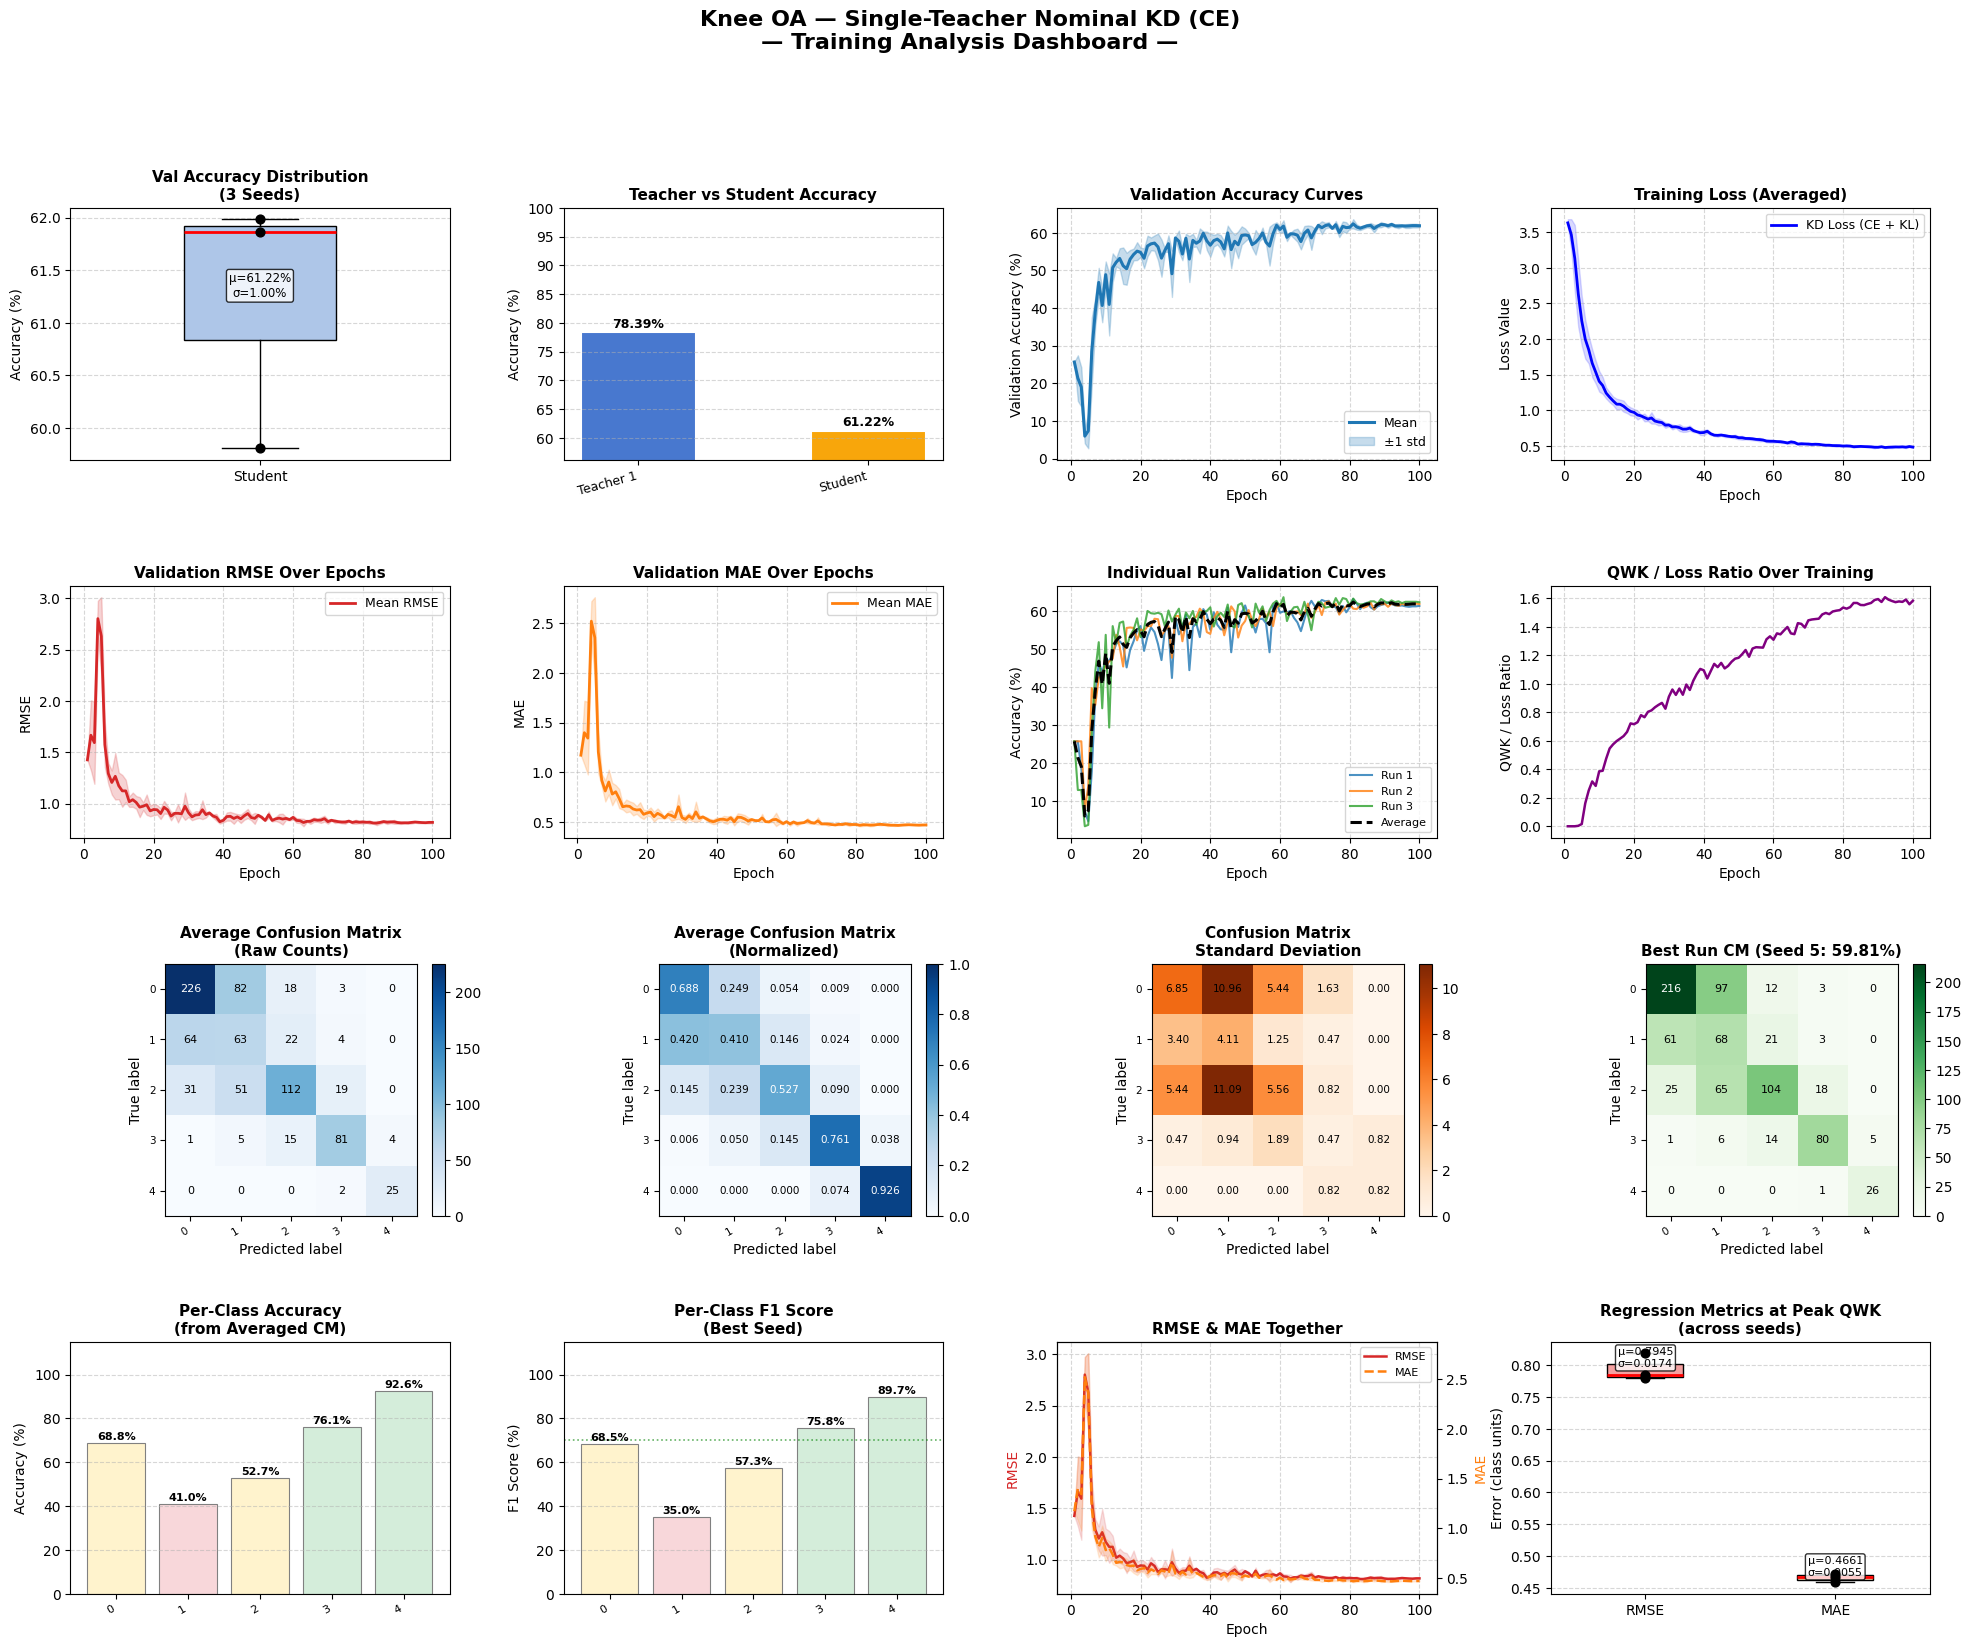

/tmp/ipykernel_58/3883002132.py:449: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig2.tight_layout(rect=[0, 0, 1, 0.97])


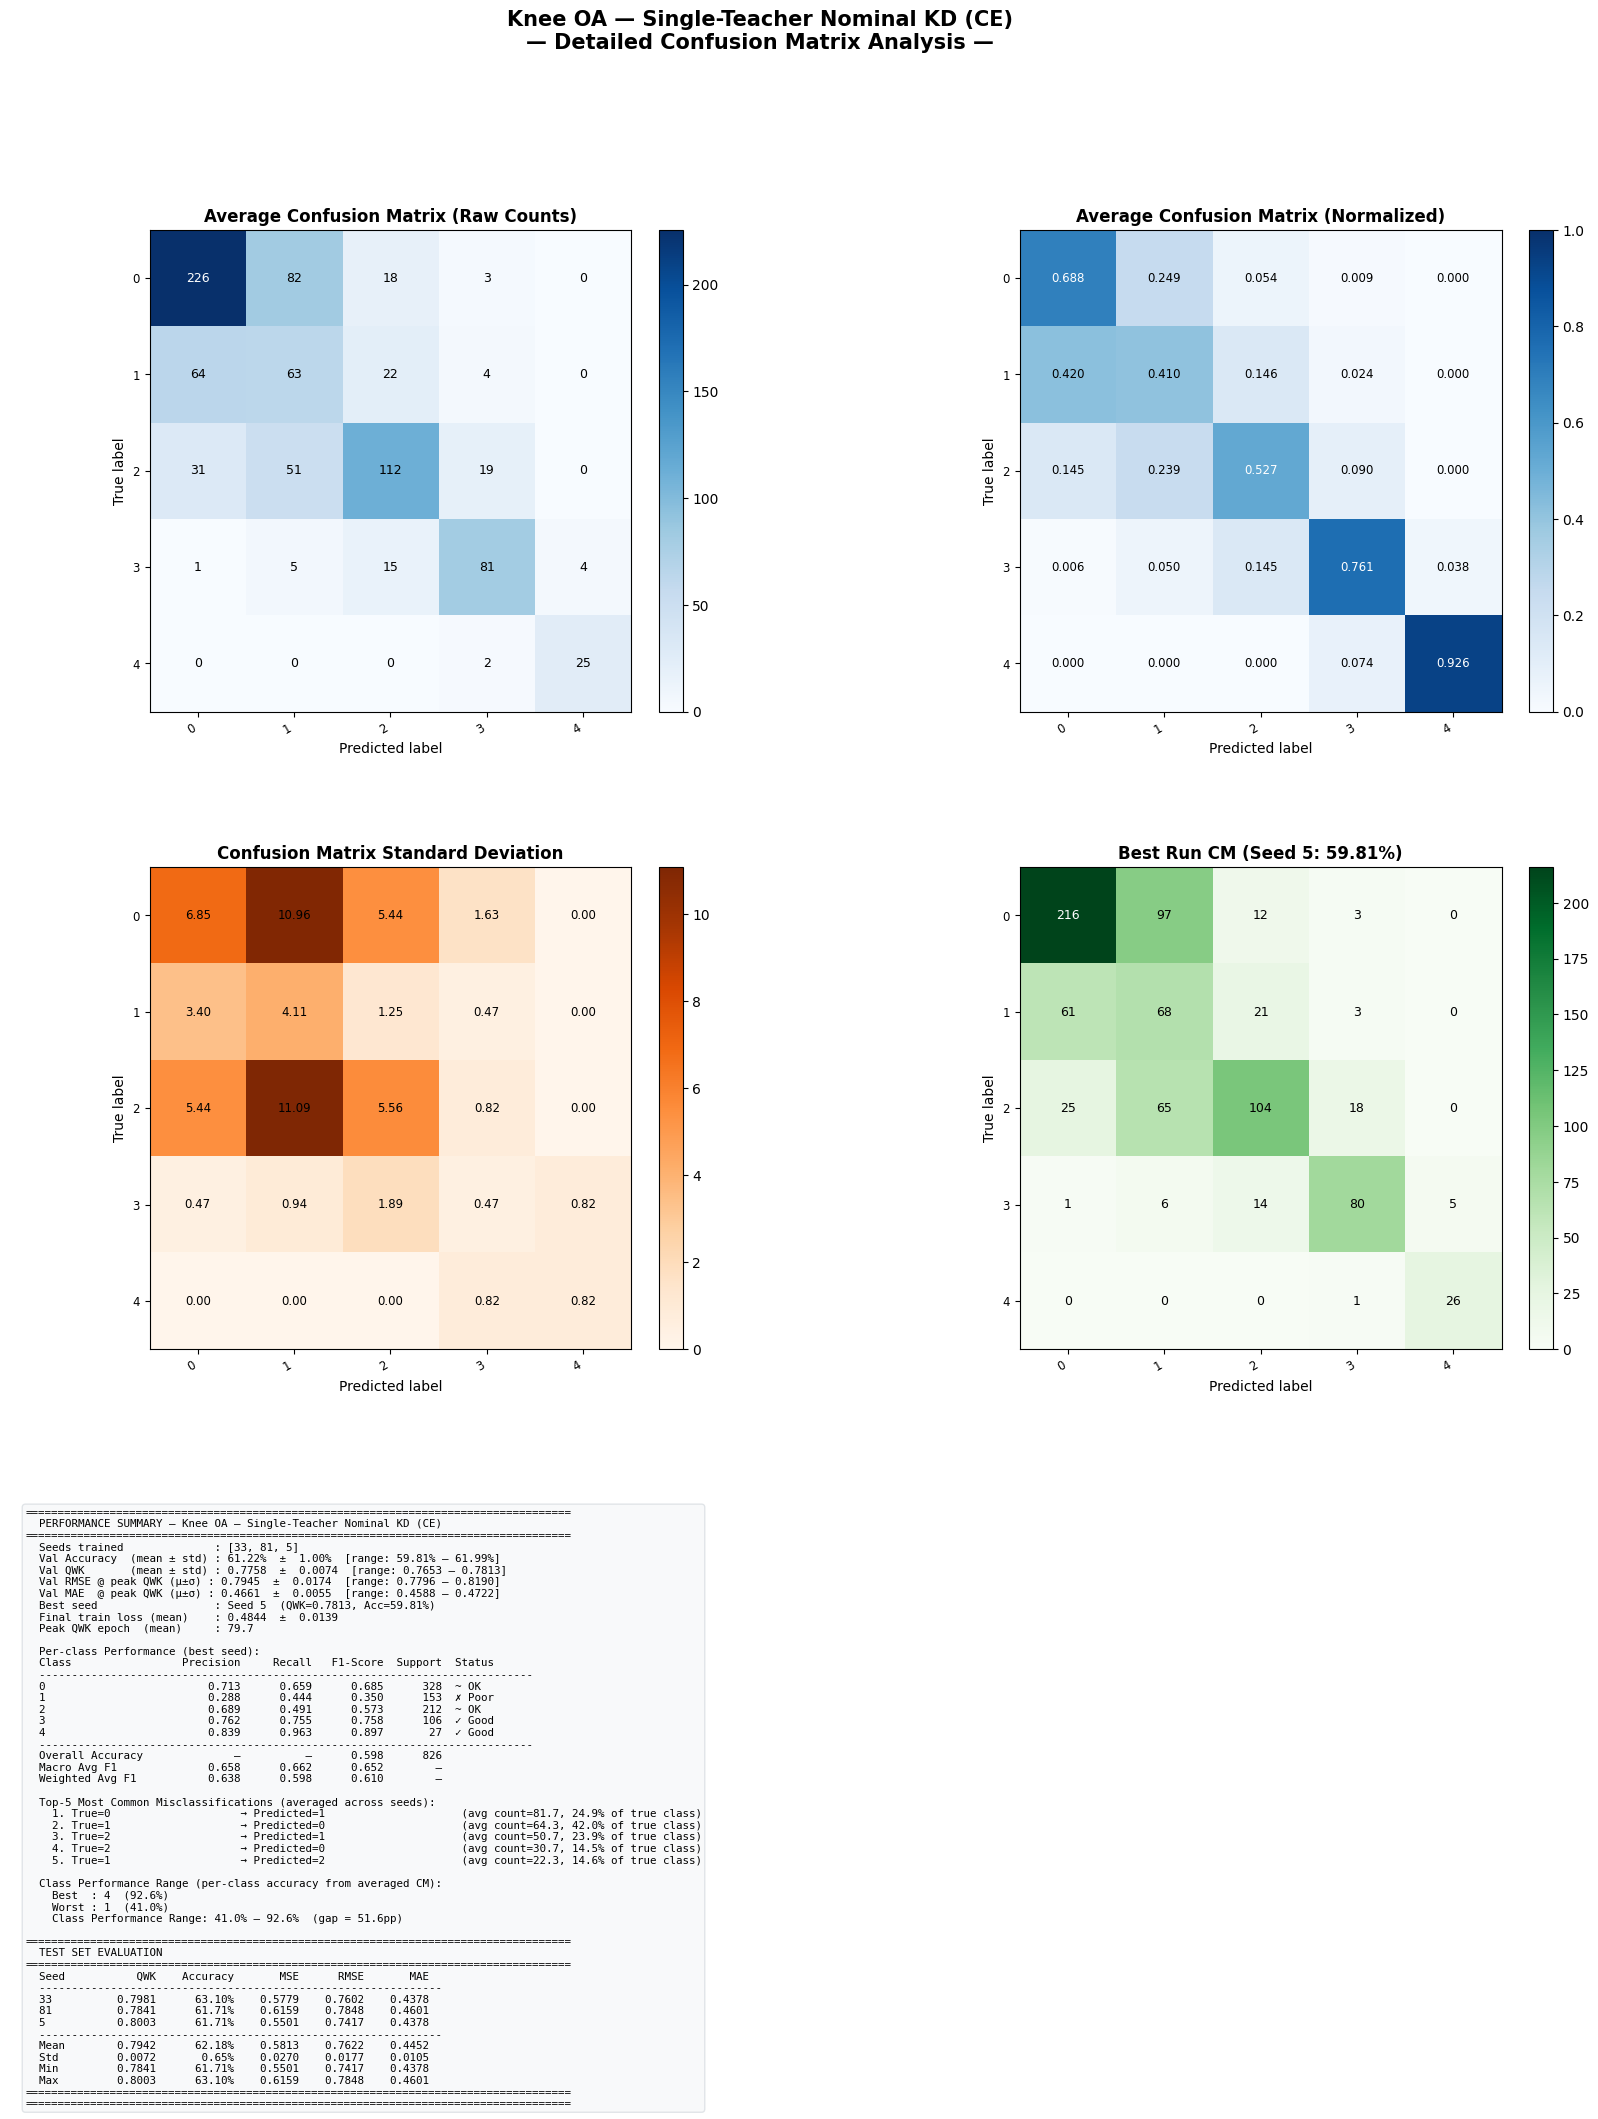

  PERFORMANCE SUMMARY — Knee OA — Single-Teacher Nominal KD (CE)
  Seeds trained              : [33, 81, 5]
  Val Accuracy  (mean ± std) : 61.22%  ±  1.00%  [range: 59.81% – 61.99%]
  Val QWK       (mean ± std) : 0.7758  ±  0.0074  [range: 0.7653 – 0.7813]
  Val RMSE @ peak QWK (μ±σ) : 0.7945  ±  0.0174  [range: 0.7796 – 0.8190]
  Val MAE  @ peak QWK (μ±σ) : 0.4661  ±  0.0055  [range: 0.4588 – 0.4722]
  Best seed                  : Seed 5  (QWK=0.7813, Acc=59.81%)
  Final train loss (mean)    : 0.4844  ±  0.0139
  Peak QWK epoch  (mean)     : 79.7

  Per-class Performance (best seed):
  Class                 Precision     Recall   F1-Score  Support  Status
  ----------------------------------------------------------------------------
  0                         0.713      0.659      0.685      328  ~ OK
  1                         0.288      0.444      0.350      153  ✗ Poor
  2                         0.689      0.491      0.573      212  ~ OK
  3                         0.762      0.

In [14]:
analyse_results(
    results,
    "Knee OA — Single-Teacher Nominal KD (CE)",
    loss_label="KD Loss (CE + KL)",
    teacher_accs=teacher_accuracies,
    test_results_list=test_results
)